# Can We Predict Dangerous Blood Pressure Drops Before They Happen?

## Why should you care about intraoperative hypotension?

If you have ever given an anaesthetic, you have watched a patient's blood pressure drift downward. Often it responds to a fluid bolus or a small dose of vasopressor. But when mean arterial pressure (MAP) stays below 65 mmHg for more than a few minutes, the consequences can be serious — and sometimes irreversible.

Here is what the evidence tells us:

- **The kidneys suffer first.** Even brief periods of MAP below 65 mmHg push renal perfusion pressure below the autoregulatory threshold. The kidneys are already under stress from surgical inflammation and nephrotoxic drugs. The relationship is dose-dependent: more minutes of hypotension means a higher chance of acute kidney injury (AKI) {cite}`walsh2013`.
- **The brain is vulnerable too.** Cerebral autoregulation depends on adequate MAP. Intraoperative hypotension is linked to postoperative stroke and delirium, particularly in elderly patients {cite}`wesselink2018`.
- **The heart cannot tolerate prolonged low pressure.** Coronary perfusion depends on diastolic blood pressure. Sustained hypotension can cause demand ischaemia — myocardial injury from oxygen supply-demand mismatch — even in patients without known coronary artery disease.
- **Mortality increases.** Large trials (including the POISE-3 trial) and observational cohorts confirm that intraoperative hypotension is independently associated with 30-day mortality {cite}`marcucci2023`.

The frustrating reality is that by the time you notice MAP has already dropped below 65 mmHg, organ damage may have begun. **What if you could see the drop coming a few minutes in advance — and act before it happens?**

That is what this chapter is about.

## What does "machine learning prediction" actually mean?

You do not need a background in computer science or statistics to follow this chapter. Let us build up the idea from scratch.

When you give an anaesthetic, you are constantly doing pattern recognition. You glance at the arterial trace and notice that MAP has been drifting downward over the last few minutes, or that the pulse pressure is widening, or that the patient had a low baseline MAP to begin with. From experience, you develop an intuition: *this patient is about to become hypotensive*.

Machine learning does the same thing — but in a more systematic, reproducible way:

> **We show a computer thousands of examples: "here is what blood pressure looked like in the 10 minutes *before* a hypotensive episode," and "here is what it looked like when everything stayed stable." The computer learns to spot the difference. Then we test whether it can apply those patterns to new patients it has never seen.**

The computer is not doing anything magical. It is looking at the same numbers you would look at — recent MAP values, trends, variability — and finding the combination that best separates "about to drop" from "staying stable."

The key difference? The computer applies the same rules every time, never gets tired, and can process far more data points simultaneously than any human.

## What will you learn in this chapter?

By the end of this notebook, you will understand:

1. **What the arterial waveform tells us** — how raw high-frequency pressure tracings get condensed into beat-by-beat MAP, systolic, and diastolic values
2. **How common hypotension really is** — its frequency, depth, duration, and timing during surgery
3. **Feature engineering** — how we take 10 minutes of blood pressure history and distil it into a handful of meaningful summary numbers (we will explain each one)
4. **Two prediction approaches** — logistic regression (simple and transparent) and random forest (more flexible) — explained in plain language
5. **How to judge whether a prediction model is actually useful** — ROC curves, calibration, and what the numbers mean in practice
6. **What this means at the bedside** — honest discussion of where we are, what works, and what does not

**No prior statistics or machine learning knowledge is assumed.** Every technical term is defined when it first appears.

**Data source:** 98 surgical cases from the [VitalDB](https://vitaldb.net) dataset with continuous arterial line monitoring.

In [1]:
# ── Cell 1: Setup & imports ──────────────────────────────────────────────────
import os, io, glob, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import requests
from pathlib import Path
from scipy import signal as sp_signal
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GroupShuffleSplit, GroupKFold, cross_val_score
from sklearn.metrics import (
    roc_auc_score, roc_curve, precision_recall_curve, average_precision_score,
    confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.calibration import calibration_curve

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 110

# Paths
BASE       = Path('/Volumes/iDrisAI/VitalDBGit')
CACHE      = BASE / 'art_cache'
TRACKS_CSV = BASE / 'vital_db' / 'tracks.csv'
LABELS_CSV = CACHE / 'labels.csv'
API_BASE   = 'https://api.vitaldb.net'

# Prediction constants
FS_BEAT    = 0.5          # Hz — beat-averaged sampling rate
DT_BEAT    = 1 / FS_BEAT  # seconds per sample = 2 s
W_SAMPLES  = int(10 * 60 * FS_BEAT)   # 10-min lookback = 300 samples
H_SAMPLES  = int(5  * 60 * FS_BEAT)   # 5-min horizon   = 150 samples
HYPO_THR   = 65           # mmHg MAP threshold

rng = np.random.default_rng(42)
print('Setup complete.')
print(f'  Lookback window : {W_SAMPLES} samples = 10 min')
print(f'  Horizon         : {H_SAMPLES} samples =  5 min')

Setup complete.
  Lookback window : 300 samples = 10 min
  Horizon         : 150 samples =  5 min


## What does the arterial line actually record?

When you place an arterial catheter — typically in the radial artery — the transducer captures a continuous pressure waveform at roughly 500 measurements per second (500 Hz). That is far more data than any human can process in real time.

Your anaesthesia monitor simplifies this by extracting three numbers from each heartbeat:

- **Systolic blood pressure (SBP):** the peak of each pulse wave — the maximum pressure generated when the left ventricle contracts. Think of it as the "push" from each heartbeat.
- **Diastolic blood pressure (DBP):** the trough between beats — the minimum pressure during ventricular relaxation. This reflects vascular tone and is critically important for coronary perfusion (the heart gets most of its blood supply during diastole).
- **Mean arterial pressure (MAP):** the average pressure over one cardiac cycle, weighted toward diastole (roughly DBP + one-third of the pulse pressure). MAP is the single number that best represents the driving pressure for organ perfusion — and it is what we are trying to predict.

In this chapter, we work with **beat-averaged** data — one MAP, SBP, and DBP value every 2 seconds (0.5 Hz). This throws away the fine waveform morphology (the shape of each individual pulse) but preserves the haemodynamic trend that matters for predicting hypotension.

Below, we first attempt to fetch raw high-frequency waveform data from the VitalDB API, and then fall back to our cached beat-averaged time series.

In [2]:
# ── Cell 2: Raw waveform fetch ───────────────────────────────────────────────
tracks = pd.read_csv(TRACKS_CSV)
art_tids = tracks[tracks['tname'] == 'SNUADC/ART'][['caseid','tid']].copy()
print(f'SNUADC/ART tracks available: {len(art_tids):,}')

labels = pd.read_csv(LABELS_CSV)
label_caseids = set(labels['caseid'].astype(int).tolist())

# Intersect: cases that have both a raw tid AND a cached parquet
parquet_caseids = {int(p.stem) for p in CACHE.glob('*.parquet')}
overlap = art_tids[art_tids['caseid'].isin(label_caseids & parquet_caseids)]
print(f'Cases in intersection (labels ∩ parquet ∩ tracks): {len(overlap)}')

# Pick 2 cases to fetch
target_cases = overlap.head(2)[['caseid','tid']].values
print('Target cases:', [(c, t[:8]+'...') for c, t in target_cases])


def fetch_track(tid, timeout=30):
    """Fetch a VitalDB track as a DataFrame (time_s, value)."""
    try:
        url = f'{API_BASE}/{tid}'
        r = requests.get(url, timeout=timeout)
        if r.status_code == 200 and len(r.content) > 10:
            df = pd.read_csv(io.StringIO(r.text))
            df.columns = ['time_s', 'value']
            df = df.dropna()
            return df
    except Exception as e:
        print(f'  fetch_track({tid[:8]}...): {e}')
    return None


raw_waves = {}   # {caseid: DataFrame(time_s, value)}
for caseid, tid in target_cases:
    print(f'Fetching caseid={caseid} tid={tid[:12]}...')
    df = fetch_track(tid)
    if df is not None and len(df) > 500:
        raw_waves[caseid] = df
        print(f'  Got {len(df):,} samples, duration {df["time_s"].max()/60:.1f} min')
    else:
        print(f'  API unavailable — will use beat-averaged cache as fallback.')

print(f'\nRaw waveforms loaded: {list(raw_waves.keys())}')

SNUADC/ART tracks available: 3,645
Cases in intersection (labels ∩ parquet ∩ tracks): 98
Target cases: [(167, '52b701a5...'), (309, '2f79ee7d...')]
Fetching caseid=167 tid=52b701a576f7...


  API unavailable — will use beat-averaged cache as fallback.
Fetching caseid=309 tid=2f79ee7d95a7...


  API unavailable — will use beat-averaged cache as fallback.

Raw waveforms loaded: []


No raw waveform data available (API unavailable). Using beat-averaged cache for visualisation.


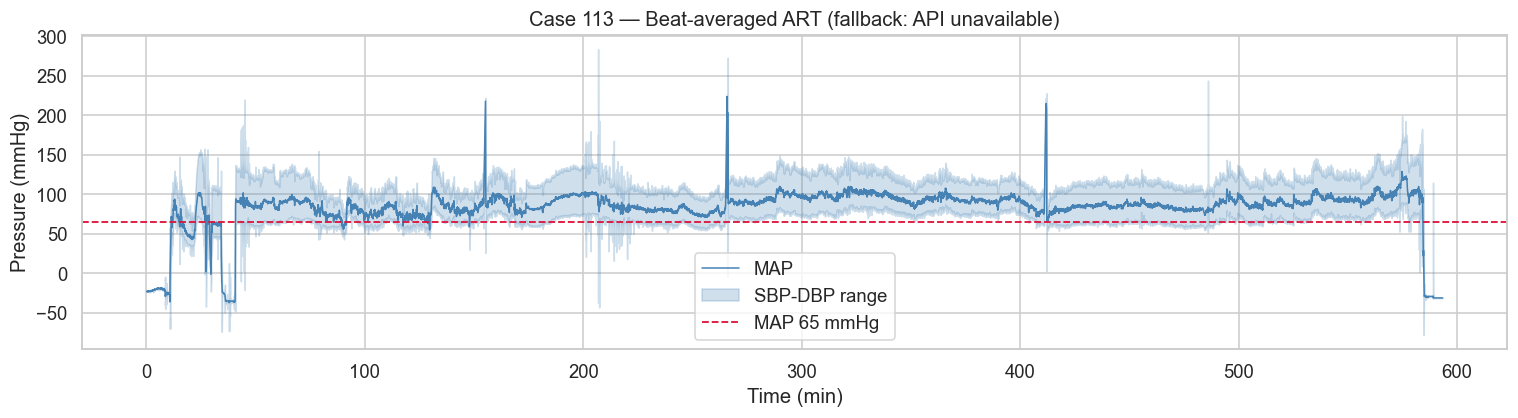

Fallback display complete.


In [3]:
# ── Cell 3: Raw waveform display ─────────────────────────────────────────────
if raw_waves:
    demo_cid = list(raw_waves.keys())[0]
    wave = raw_waves[demo_cid].copy()
    wave = wave[(wave['value'] > 20) & (wave['value'] < 300)]  # plausibility

    # Estimate true sampling rate
    diffs = np.diff(wave['time_s'].values)
    fs_est = 1.0 / np.median(diffs[diffs > 0])
    print(f'Case {demo_cid}: estimated Fs = {fs_est:.1f} Hz, {len(wave):,} samples')

    fig = plt.figure(figsize=(16, 10))
    gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.35)

    # ── Panel A: full-case overview (downsampled to ~5 Hz) ──
    ax_full = fig.add_subplot(gs[0, :])
    ds_factor = max(1, int(fs_est / 5))
    wave_ds   = wave.iloc[::ds_factor]
    ax_full.plot(wave_ds['time_s'] / 60, wave_ds['value'], lw=0.4, color='steelblue', alpha=0.85)
    ax_full.axhline(HYPO_THR, color='crimson', ls='--', lw=1.2, label='MAP 65 mmHg')
    ax_full.set(xlabel='Time (min)', ylabel='Arterial Pressure (mmHg)',
                title=f'Case {demo_cid} — Full Case Overview (downsampled to ~5 Hz)')
    ax_full.legend(fontsize=9)

    # ── Panel B: 30-second zoomed window (full 500 Hz) ──
    ax_zoom = fig.add_subplot(gs[1, 0])
    mid_t   = wave['time_s'].median()
    win     = wave[(wave['time_s'] >= mid_t) & (wave['time_s'] < mid_t + 30)].copy()
    win_t_rel = win['time_s'].values - win['time_s'].iloc[0]
    ax_zoom.plot(win_t_rel, win['value'].values, lw=0.9, color='darkgreen')
    ax_zoom.set(xlabel='Time within window (s)', ylabel='Arterial Pressure (mmHg)',
                title='30-second Window — Full Resolution (~500 Hz)')

    # ── Panel C: beat detection on 30-s window ──
    ax_beat = fig.add_subplot(gs[1, 1])
    win_vals = win['value'].values
    win_t    = win_t_rel
    min_dist = max(1, int(fs_est * 0.4))
    sbp_idx, _  = sp_signal.find_peaks(win_vals, distance=min_dist, prominence=15)
    dbp_idx, _  = sp_signal.find_peaks(-win_vals, distance=min_dist, prominence=8)

    ax_beat.plot(win_t, win_vals, lw=0.9, color='darkgreen', label='ART')
    ax_beat.scatter(win_t[sbp_idx], win_vals[sbp_idx], s=30, c='red',
                    zorder=5, label=f'Systole ({len(sbp_idx)} peaks)')
    ax_beat.scatter(win_t[dbp_idx], win_vals[dbp_idx], s=30, c='navy',
                    zorder=5, label=f'Diastole ({len(dbp_idx)} troughs)')
    if len(sbp_idx) > 0 and len(dbp_idx) > 0:
        sbp_m = np.mean(win_vals[sbp_idx])
        dbp_m = np.mean(win_vals[dbp_idx])
        pp_m  = sbp_m - dbp_m
        ax_beat.axhline(sbp_m, color='red',  ls=':', lw=0.8, alpha=0.6)
        ax_beat.axhline(dbp_m, color='navy', ls=':', lw=0.8, alpha=0.6)
        ax_beat.text(win_t[-1]*0.65, sbp_m+2, f'SBP≈{sbp_m:.0f}', color='red',  fontsize=8)
        ax_beat.text(win_t[-1]*0.65, dbp_m-6, f'DBP≈{dbp_m:.0f}', color='navy', fontsize=8)
        ax_beat.text(win_t[-1]*0.65, (sbp_m+dbp_m)/2,
                     f'PP≈{pp_m:.0f}', color='purple', fontsize=8)
    ax_beat.set(xlabel='Time (s)', ylabel='Pressure (mmHg)',
                title='Beat Detection — Systole & Diastole')
    ax_beat.legend(fontsize=8)

    fig.suptitle(f'Arterial-Line Raw Waveform — Case {demo_cid}', fontsize=14, fontweight='bold')
    plt.savefig(BASE / 'art_hypotension_fig3_waveform.png', bbox_inches='tight')
    plt.show()
    print(f'Beat detection: {len(sbp_idx)} systolic peaks, {len(dbp_idx)} diastolic troughs in 30 s')
    if len(sbp_idx) >= 2:
        ibi_s  = np.diff(win_t[sbp_idx])
        hr_est = 60 / np.mean(ibi_s)
        print(f'Estimated HR: {hr_est:.1f} bpm  (mean IBI {np.mean(ibi_s)*1000:.0f} ms)')
else:
    print('No raw waveform data available (API unavailable). Using beat-averaged cache for visualisation.')
    demo_cid = sorted(parquet_caseids)[0]
    df_demo  = pd.read_parquet(CACHE / f'{demo_cid}.parquet')
    # Align SBP, DBP on common time_s points
    df_mbp = df_demo[df_demo['signal'] == 'ART_MBP'][['time_s','value']].rename(columns={'value':'mbp'})
    df_sbp = df_demo[df_demo['signal'] == 'ART_SBP'][['time_s','value']].rename(columns={'value':'sbp'})
    df_dbp = df_demo[df_demo['signal'] == 'ART_DBP'][['time_s','value']].rename(columns={'value':'dbp'})
    merged = df_mbp.merge(df_sbp, on='time_s', how='inner').merge(df_dbp, on='time_s', how='inner')
    merged = merged.sort_values('time_s')
    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(merged['time_s']/60, merged['mbp'], lw=1, label='MAP', color='steelblue')
    ax.fill_between(merged['time_s']/60, merged['dbp'], merged['sbp'],
                    alpha=0.25, color='steelblue', label='SBP-DBP range')
    ax.axhline(HYPO_THR, color='crimson', ls='--', lw=1.2, label='MAP 65 mmHg')
    ax.set(xlabel='Time (min)', ylabel='Pressure (mmHg)',
           title=f'Case {demo_cid} — Beat-averaged ART (fallback: API unavailable)')
    ax.legend()
    plt.tight_layout()
    plt.savefig(BASE / 'art_hypotension_fig3_waveform.png', bbox_inches='tight')
    plt.show()
    print('Fallback display complete.')

## How stable is blood pressure during surgery?

Before we try to predict anything, we need to understand what we are dealing with. Is MAP rock-steady throughout a surgical case, or does it wander around? How much variability is there between patients?

The plots below answer these questions using our cohort of 98 cases:

- **Case duration** — how long these surgeries lasted. Longer cases give us more data to learn from, but also more opportunity for hypotensive episodes.
- **MAP distribution** — the overall spread of MAP values across all patients and time points. Pay attention to how many measurements fall below the 65 mmHg threshold — this tells you how common hypotension is in this cohort.
- **Per-case MAP** — each dot is one patient's average MAP, with error bars showing variability. You will notice that some patients run consistently low throughout their case, while others are comfortably above 65 mmHg the whole time.
- **Autocorrelation (ACF/PACF)** — these plots answer a clinically important question: *does the current MAP value tell us anything about what MAP will be in a few minutes?* Strong autocorrelation (which we see here) means **yes** — blood pressure tends to drift gradually rather than jumping randomly. This is excellent news for prediction, because it means recent trends carry useful information about the near future.
- **Power spectrum** — another way of looking at MAP variability. The dominance of low-frequency oscillations (slow drifts over minutes) confirms that blood pressure changes are gradual and therefore potentially predictable over clinically useful timescales.

In [4]:
# ── Cell 4: Raw waveform characterisation ────────────────────────────────────
if raw_waves:
    fig, axes = plt.subplots(2, 3, figsize=(16, 9))
    axes = axes.flatten()

    for ax_i, (cid, wave_raw) in enumerate(raw_waves.items()):
        wave_c = wave_raw[(wave_raw['value'] > 20) & (wave_raw['value'] < 300)].copy()
        diffs_c = np.diff(wave_c['time_s'].values)
        diffs_c = diffs_c[(diffs_c > 0) & (diffs_c < 0.1)]
        fs_c    = 1.0 / np.median(diffs_c) if len(diffs_c) > 0 else 500.0
        print(f'Case {cid}: Fs={fs_c:.1f} Hz, {len(wave_c):,} valid samples, '
              f'range=[{wave_c["value"].min()}, {wave_c["value"].max()}] mmHg')

        # Beat detection for HRV
        vals_c = wave_c['value'].values
        min_d  = max(1, int(fs_c * 0.4))
        peaks_c, _ = sp_signal.find_peaks(vals_c, distance=min_d, prominence=15)
        if len(peaks_c) >= 2:
            ibi_c = np.diff(wave_c['time_s'].values[peaks_c])  # IBI in seconds
            ibi_c = ibi_c[(ibi_c > 0.3) & (ibi_c < 2.0)]      # physiological range
            hr_series = 60.0 / ibi_c

            # RMSSD
            rmssd = np.sqrt(np.mean(np.diff(ibi_c * 1000)**2))
            # pNN50
            pnn50 = 100.0 * np.mean(np.abs(np.diff(ibi_c * 1000)) > 50)
            print(f'  Beats={len(peaks_c)}, HR={np.mean(hr_series):.1f}±{np.std(hr_series):.1f} bpm, '
                  f'RMSSD={rmssd:.1f} ms, pNN50={pnn50:.1f}%')
        else:
            ibi_c, hr_series = np.array([]), np.array([])
            rmssd, pnn50 = np.nan, np.nan
            print(f'  Insufficient beats detected.')

        col = ax_i * 3
        if col + 2 < len(axes):
            # Amplitude histogram
            axes[col].hist(wave_c['value'], bins=80, color='steelblue', edgecolor='none', alpha=0.8)
            axes[col].axvline(HYPO_THR, color='crimson', ls='--', lw=1.5, label='MAP 65')
            axes[col].set(title=f'Case {cid}: Amplitude Distribution',
                          xlabel='Pressure (mmHg)', ylabel='Count')
            axes[col].legend(fontsize=8)

            # HR time series
            if len(hr_series) > 0:
                beat_t = wave_c['time_s'].values[peaks_c[1:]] / 60
                beat_t = beat_t[:len(hr_series)]
                axes[col+1].plot(beat_t, hr_series, lw=0.7, color='darkorange')
                axes[col+1].set(title=f'Case {cid}: Beat-to-Beat HR\n(RMSSD={rmssd:.1f} ms, pNN50={pnn50:.1f}%)',
                                xlabel='Time (min)', ylabel='HR (bpm)')

                # HRV power spectrum (Welch)
                ibi_uniform = np.interp(
                    np.arange(0, len(ibi_c) * 0.5, 0.5 / 4),
                    np.cumsum(ibi_c) - ibi_c[0],
                    ibi_c
                )
                fs_hrv = 4.0  # 4 Hz resample
                freqs_hrv, psd_hrv = sp_signal.welch(ibi_uniform, fs=fs_hrv, nperseg=min(256, len(ibi_uniform)//2))
                axes[col+2].semilogy(freqs_hrv, psd_hrv, lw=1.2, color='purple')
                axes[col+2].axvspan(0.04, 0.15, alpha=0.15, color='blue',  label='LF (0.04-0.15 Hz)')
                axes[col+2].axvspan(0.15, 0.40, alpha=0.15, color='green', label='HF (0.15-0.40 Hz)')
                axes[col+2].set(title=f'Case {cid}: IBI Power Spectrum',
                                xlabel='Frequency (Hz)', ylabel='PSD (s²/Hz)')
                axes[col+2].legend(fontsize=7)
            else:
                axes[col+1].text(0.5, 0.5, 'Insufficient beats', ha='center', va='center')
                axes[col+2].text(0.5, 0.5, 'Insufficient beats', ha='center', va='center')

    plt.suptitle('Raw Waveform Characterisation', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(BASE / 'art_hypotension_fig4_rawchar.png', bbox_inches='tight')
    plt.show()
else:
    print('No raw waveform available — skipping Cell 4 characterisation (API unavailable).')

No raw waveform available — skipping Cell 4 characterisation (API unavailable).


In [5]:
# ── Cell 5: Load beat-averaged time series ───────────────────────────────────
parquets = sorted(CACHE.glob('*.parquet'))
print(f'Parquet files found: {len(parquets)}')

art_raw = pd.concat([pd.read_parquet(p) for p in parquets], ignore_index=True)
print(f'Total rows (long format): {len(art_raw):,}')
print(f'Signals: {art_raw["signal"].unique()}')

# Plausibility filter
limits = {'ART_MBP': (20, 180), 'ART_SBP': (40, 260), 'ART_DBP': (10, 150)}
mask = art_raw.apply(
    lambda r: limits.get(r['signal'], (0, 1000))[0] <= r['value'] <= limits.get(r['signal'], (0, 1000))[1],
    axis=1
)
art = art_raw[mask].copy()
print(f'After plausibility filter: {len(art):,} ({100*len(art)/len(art_raw):.1f}% retained)')

# Pivot to wide format: one row per (caseid, time_s)
art_wide = art.pivot_table(index=['caseid','time_s'], columns='signal', values='value').reset_index()
art_wide.columns.name = None
art_wide.rename(columns={'ART_MBP': 'mbp', 'ART_SBP': 'sbp', 'ART_DBP': 'dbp'}, inplace=True)
art_wide = art_wide.sort_values(['caseid','time_s']).reset_index(drop=True)
print(f'Wide format rows: {len(art_wide):,}  Cases: {art_wide["caseid"].nunique()}')

# Merge case-level labels
labels = pd.read_csv(LABELS_CSV)
keep_cols = ['caseid','aki_any','icu_days','age','preop_cr','sex','weight']
keep_cols = [c for c in keep_cols if c in labels.columns]
art_wide = art_wide.merge(labels[keep_cols], on='caseid', how='left')
print(f'After label merge: {art_wide["aki_any"].notna().sum():,} rows with AKI label')
print(f'AKI distribution: {art_wide.drop_duplicates("caseid")["aki_any"].value_counts().to_dict()}')

art_wide.head(3)

Parquet files found: 100


Total rows (long format): 2,200,560
Signals: <ArrowStringArray>
['ART_MBP', 'ART_SBP', 'ART_DBP']
Length: 3, dtype: str


After plausibility filter: 2,078,081 (94.4% retained)


Wide format rows: 704,808  Cases: 98
After label merge: 704,808 rows with AKI label
AKI distribution: {1: 50, 0: 48}


,caseid,time_s,dbp,mbp,sbp,aki_any,icu_days,age,preop_cr,sex,weight
0,113,637.669,58.0,NaN,NaN,1,1,67.0,0.74,M,53.45
1,113,639.669,58.0,NaN,NaN,1,1,67.0,0.74,M,53.45
2,113,645.668,NaN,NaN,46.0,1,1,67.0,0.74,M,53.45


Case-level summary:
       duration_min  mbp_mean  mbp_std
count          98.0      97.0     97.0
mean          248.0      81.4     13.2
std           140.4       9.4      2.7
min            40.3      51.8      6.8
25%           153.3      76.0     11.1
50%           209.2      81.8     13.0
75%           333.4      87.7     14.9
max           759.8     103.5     20.2


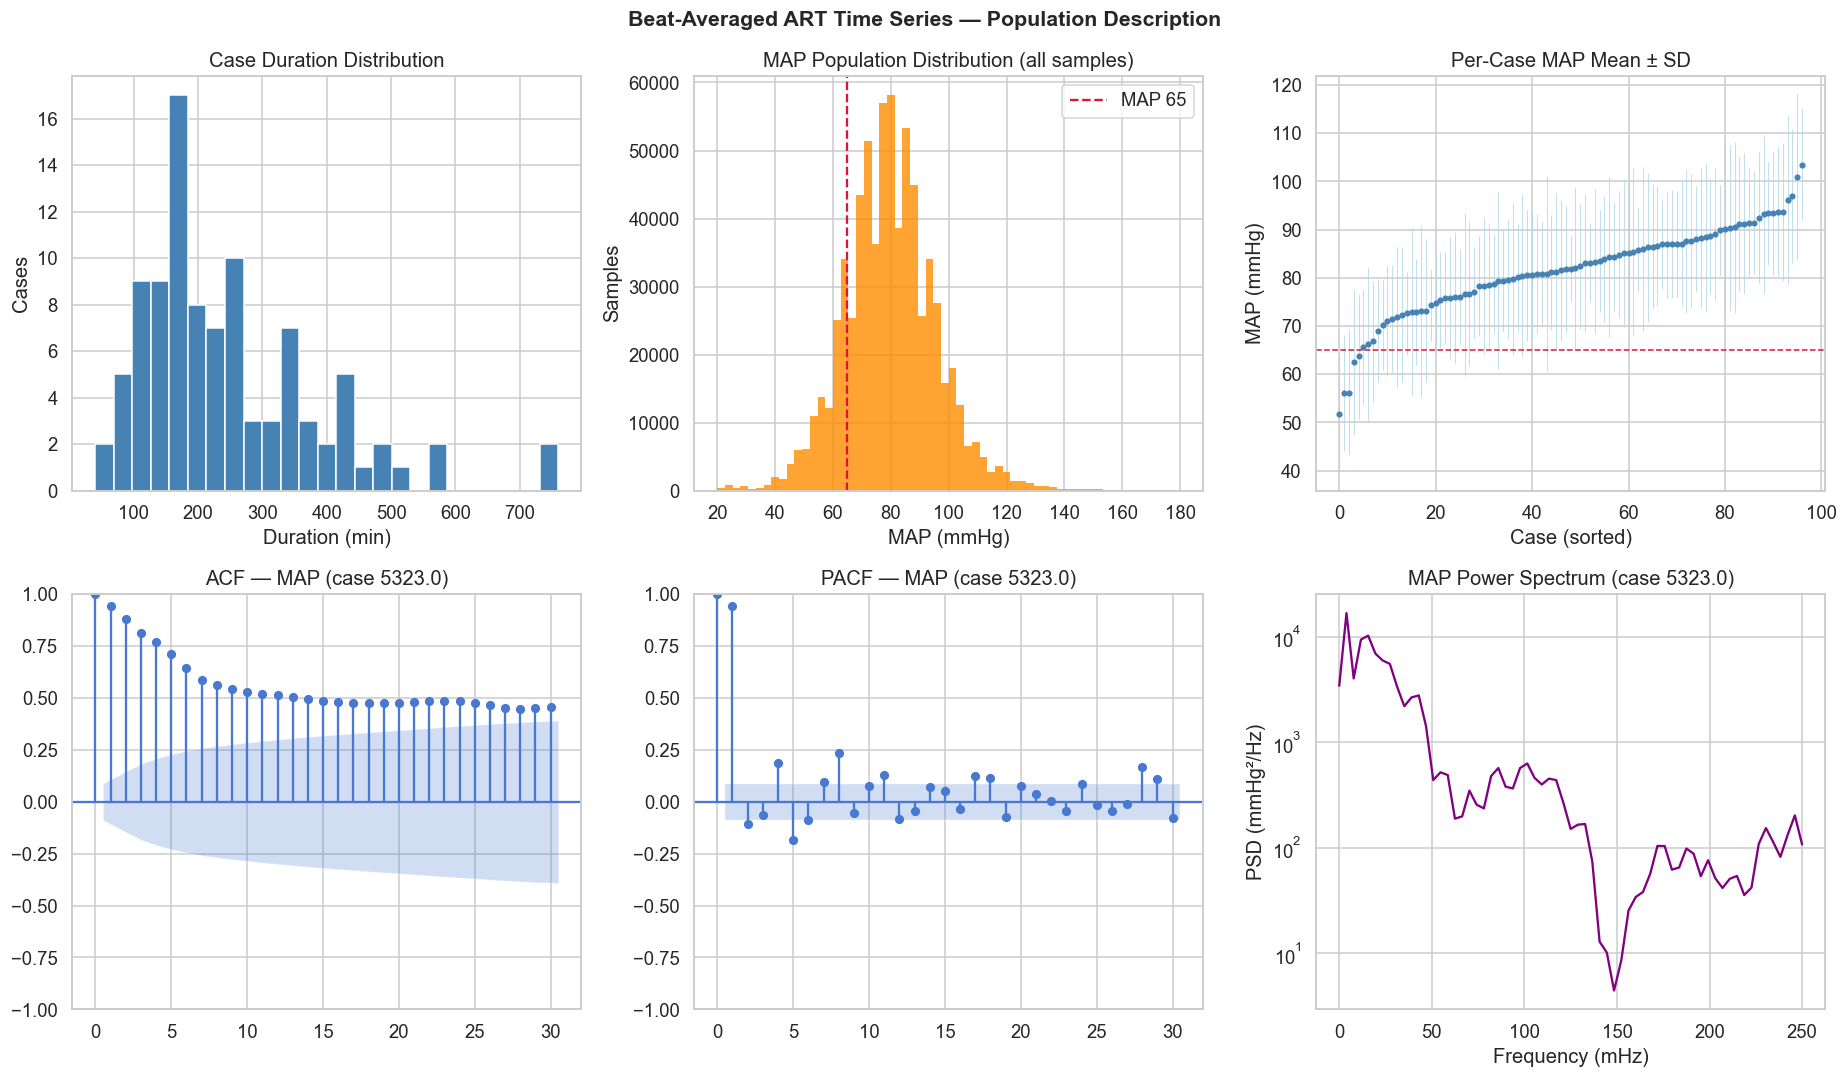


Augmented Dickey-Fuller test (p-values across all cases):


  Median p-value: 0.0000
  % cases with p<0.05 (stationary): 93.8%
  % cases with p>0.05 (unit root):  6.2%


In [6]:
# ── Cell 6: Time series description ──────────────────────────────────────────
# Case duration distribution
case_stats = art_wide.groupby('caseid').agg(
    n_samples=('time_s','count'),
    duration_min=('time_s', lambda x: (x.max() - x.min()) / 60),
    mbp_mean=('mbp','mean'),
    mbp_std=('mbp','std'),
    mbp_q25=('mbp', lambda x: x.quantile(0.25)),
    mbp_q75=('mbp', lambda x: x.quantile(0.75))
).reset_index()

print('Case-level summary:')
print(case_stats[['duration_min','mbp_mean','mbp_std']].describe().round(1).to_string())

fig, axes = plt.subplots(2, 3, figsize=(17, 10))

# Duration distribution
axes[0,0].hist(case_stats['duration_min'], bins=25, color='steelblue', edgecolor='white')
axes[0,0].set(title='Case Duration Distribution', xlabel='Duration (min)', ylabel='Cases')

# MAP population distribution
axes[0,1].hist(art_wide['mbp'].dropna(), bins=60, color='darkorange', edgecolor='none', alpha=0.8)
axes[0,1].axvline(HYPO_THR, color='crimson', ls='--', lw=1.5, label='MAP 65')
axes[0,1].set(title='MAP Population Distribution (all samples)', xlabel='MAP (mmHg)', ylabel='Samples')
axes[0,1].legend()

# Per-case MAP mean ± SD
order = case_stats.sort_values('mbp_mean')['caseid'].values
axes[0,2].errorbar(
    range(len(order)), case_stats.set_index('caseid').loc[order,'mbp_mean'],
    yerr=case_stats.set_index('caseid').loc[order,'mbp_std'],
    fmt='o', ms=3, lw=0.5, color='steelblue', ecolor='lightblue'
)
axes[0,2].axhline(HYPO_THR, color='crimson', ls='--', lw=1)
axes[0,2].set(title='Per-Case MAP Mean ± SD', xlabel='Case (sorted)', ylabel='MAP (mmHg)')

# ACF / PACF for a representative case
rep_cid = case_stats.sort_values('duration_min').iloc[len(case_stats)//2]['caseid']
rep_mbp = art_wide[art_wide['caseid'] == rep_cid]['mbp'].dropna().values[:500]
if len(rep_mbp) >= 40:
    plot_acf(rep_mbp,  ax=axes[1,0], lags=30, title=f'ACF — MAP (case {rep_cid})')
    plot_pacf(rep_mbp, ax=axes[1,1], lags=30, title=f'PACF — MAP (case {rep_cid})', method='ols')

# Welch PSD of MAP
freqs_w, psd_w = sp_signal.welch(rep_mbp, fs=FS_BEAT, nperseg=min(128, len(rep_mbp)//2))
axes[1,2].semilogy(freqs_w * 1000, psd_w, lw=1.5, color='purple')
axes[1,2].set(title=f'MAP Power Spectrum (case {rep_cid})',
              xlabel='Frequency (mHz)', ylabel='PSD (mmHg²/Hz)')

plt.suptitle('Beat-Averaged ART Time Series — Population Description', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(BASE / 'art_hypotension_fig6_tsdesc.png', bbox_inches='tight')
plt.show()

# Augmented Dickey-Fuller stationarity test across cases
print('\nAugmented Dickey-Fuller test (p-values across all cases):')
adf_pvals = []
for cid, grp in art_wide.groupby('caseid'):
    mbp_c = grp['mbp'].dropna().values
    if len(mbp_c) >= 20:
        try:
            res = adfuller(mbp_c, maxlag=10, autolag='AIC')
            adf_pvals.append(res[1])
        except Exception:
            pass
adf_pvals = np.array(adf_pvals)
print(f'  Median p-value: {np.median(adf_pvals):.4f}')
print(f'  % cases with p<0.05 (stationary): {100*np.mean(adf_pvals < 0.05):.1f}%')
print(f'  % cases with p>0.05 (unit root):  {100*np.mean(adf_pvals >= 0.05):.1f}%')

Hypotension prevalence: 107,390 / 704,808 samples = 15.2%



Total hypotension episodes: 2652
       duration_min  depth_mmhg
count       2652.00     2652.00
mean           1.39        5.48
std            4.97        8.47
min            0.00      -28.00
25%            0.03        1.00
50%            0.20        2.00
75%            0.80        5.41
max          136.77       45.00


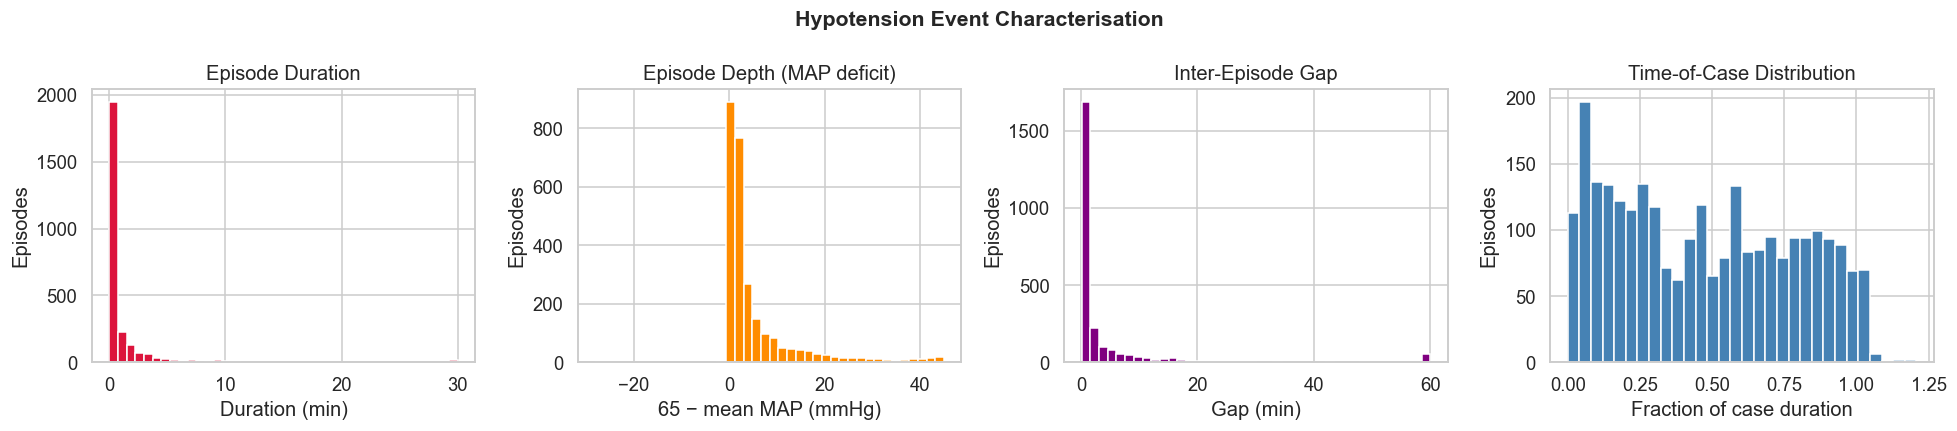

In [7]:
# ── Cell 7: Hypotension event characterisation ───────────────────────────────
art_wide['hypo'] = (art_wide['mbp'] < HYPO_THR).astype('Int8')

# Overall prevalence
total_valid = art_wide['hypo'].notna().sum()
total_hypo  = art_wide['hypo'].sum()
prevalence  = 100 * total_hypo / total_valid
print(f'Hypotension prevalence: {total_hypo:,} / {total_valid:,} samples = {prevalence:.1f}%')


def extract_hypo_events(hypo_series, gap_samples=2):
    """Extract contiguous hypotension episodes (merging gaps <= gap_samples)."""
    s = hypo_series.fillna(0).astype(int).values
    events = []
    in_event, start = False, 0
    gap_count = 0
    for i, v in enumerate(s):
        if v == 1:
            if not in_event:
                start = i
                in_event = True
            gap_count = 0
        else:
            if in_event:
                gap_count += 1
                if gap_count > gap_samples:
                    events.append((start, i - gap_count))
                    in_event = False
                    gap_count = 0
    if in_event:
        events.append((start, len(s)-1))
    return events


all_events, inter_gaps, time_fracs = [], [], []
for cid, grp in art_wide.groupby('caseid'):
    grp = grp.sort_values('time_s').reset_index(drop=True)
    dur_s = grp['time_s'].max() - grp['time_s'].min()
    if dur_s < 600:
        continue
    evts = extract_hypo_events(grp['hypo'])
    prev_end = None
    for (s_i, e_i) in evts:
        t_start = grp.loc[s_i, 'time_s']
        t_end   = grp.loc[e_i, 'time_s']
        dur_evt  = (t_end - t_start) / 60  # minutes
        mbp_seg  = grp.loc[s_i:e_i, 'mbp'].dropna()
        depth    = HYPO_THR - mbp_seg.mean() if len(mbp_seg) > 0 else np.nan
        frac     = t_start / dur_s
        all_events.append({'caseid': cid, 'duration_min': dur_evt, 'depth_mmhg': depth, 'time_frac': frac})
        time_fracs.append(frac)
        if prev_end is not None:
            inter_gaps.append((t_start - grp.loc[prev_end, 'time_s']) / 60)
        prev_end = e_i

evdf = pd.DataFrame(all_events)
print(f'\nTotal hypotension episodes: {len(evdf)}')
print(evdf[['duration_min','depth_mmhg']].describe().round(2).to_string())

fig, axes = plt.subplots(1, 4, figsize=(18, 4))

axes[0].hist(evdf['duration_min'].clip(0,30), bins=40, color='crimson', edgecolor='white')
axes[0].set(title='Episode Duration', xlabel='Duration (min)', ylabel='Episodes')

axes[1].hist(evdf['depth_mmhg'].dropna(), bins=40, color='darkorange', edgecolor='white')
axes[1].set(title='Episode Depth (MAP deficit)', xlabel='65 − mean MAP (mmHg)', ylabel='Episodes')

if inter_gaps:
    axes[2].hist(np.array(inter_gaps).clip(0, 60), bins=40, color='purple', edgecolor='white')
    axes[2].set(title='Inter-Episode Gap', xlabel='Gap (min)', ylabel='Episodes')
else:
    axes[2].text(0.5, 0.5, 'No inter-episode gaps', ha='center', va='center')

axes[3].hist(evdf['time_frac'], bins=30, color='steelblue', edgecolor='white')
axes[3].set(title='Time-of-Case Distribution', xlabel='Fraction of case duration', ylabel='Episodes')

plt.suptitle('Hypotension Event Characterisation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(BASE / 'art_hypotension_fig7_events.png', bbox_inches='tight')
plt.show()

In [8]:
# ── Cell 8: Sliding-window feature engineering ───────────────────────────────
print(f'Engineering features: lookback W={W_SAMPLES} samples ({W_SAMPLES*DT_BEAT/60:.0f} min)')

feature_dfs = []

for cid, grp in art_wide.groupby('caseid'):
    grp = grp.sort_values('time_s').reset_index(drop=True)
    n   = len(grp)
    if n < W_SAMPLES + H_SAMPLES + 10:
        continue

    mbp = grp['mbp'].values.astype(float)
    sbp = grp['sbp'].values.astype(float) if 'sbp' in grp else np.full(n, np.nan)
    dbp = grp['dbp'].values.astype(float) if 'dbp' in grp else np.full(n, np.nan)
    t   = grp['time_s'].values

    # Baseline: mean of first 5 min (~150 samples)
    base_n   = min(int(5 * 60 * FS_BEAT), n)
    baseline = np.nanmean(mbp[:base_n])

    rows = []
    for i in range(W_SAMPLES, n - H_SAMPLES):
        w_mbp = mbp[i - W_SAMPLES:i]
        w_sbp = sbp[i - W_SAMPLES:i]
        w_dbp = dbp[i - W_SAMPLES:i]
        w_t   = t[i - W_SAMPLES:i]

        # Slope (mmHg/min)
        valid_mask = ~np.isnan(w_mbp)
        if valid_mask.sum() >= 10:
            x_fit = (w_t[valid_mask] - w_t[valid_mask][0]) / 60
            slope = np.polyfit(x_fit, w_mbp[valid_mask], 1)[0]
        else:
            slope = np.nan

        row = {
            'caseid'     : cid,
            'time_s'     : t[i],
            'mbp_now'    : mbp[i],
            'mbp_mean_W' : np.nanmean(w_mbp),
            'mbp_min_W'  : np.nanmin(w_mbp),
            'mbp_std_W'  : np.nanstd(w_mbp),
            'mbp_slope_W': slope,
            'sbp_mean_W' : np.nanmean(w_sbp),
            'dbp_mean_W' : np.nanmean(w_dbp),
            'pp_mean_W'  : np.nanmean(w_sbp - w_dbp),
            'pct_hypo_W' : 100 * np.nanmean(w_mbp < HYPO_THR),
            'mbp_lag1'   : mbp[i-1]  if i >= 1 else np.nan,
            'mbp_lag2'   : mbp[i-2]  if i >= 2 else np.nan,
            'mbp_lag5'   : mbp[i-5]  if i >= 5 else np.nan,
            'mbp_delta'  : mbp[i] - baseline,
        }
        rows.append(row)

    if rows:
        feature_dfs.append(pd.DataFrame(rows))

feat_df = pd.concat(feature_dfs, ignore_index=True)
print(f'Feature matrix shape: {feat_df.shape}')
print(f'Cases with features: {feat_df["caseid"].nunique()}')
print(f'NaN fraction per feature:')
FEAT_COLS = ['mbp_mean_W','mbp_min_W','mbp_std_W','mbp_slope_W',
             'sbp_mean_W','dbp_mean_W','pp_mean_W','pct_hypo_W',
             'mbp_lag1','mbp_lag2','mbp_lag5','mbp_delta']
print(feat_df[FEAT_COLS].isna().mean().round(3).to_string())

Engineering features: lookback W=300 samples (10 min)


Feature matrix shape: (661149, 15)
Cases with features: 97
NaN fraction per feature:
mbp_mean_W     0.000
mbp_min_W      0.000
mbp_std_W      0.000
mbp_slope_W    0.000
sbp_mean_W     0.000
dbp_mean_W     0.000
pp_mean_W      0.000
pct_hypo_W     0.000
mbp_lag1       0.005
mbp_lag2       0.005
mbp_lag5       0.005
mbp_delta      0.015


## What did we just calculate? A plain-language guide to the features

The code above looked at a sliding 10-minute window of blood pressure data and calculated 12 summary numbers (called **features**) for each moment in time. Think of these as the "vital signs of the vital sign" — a compact summary of what blood pressure has been doing recently.

Here is what each one means:

| Feature | Plain-language meaning |
|---------|----------------------|
| **mbp_mean_W** | The average MAP over the last 10 minutes. A low value means the patient has been running at a lower blood pressure recently. |
| **mbp_min_W** | The lowest MAP reading in the last 10 minutes. Has there been a worrying dip? |
| **mbp_std_W** | How much MAP has been bouncing around (its variability). High variability often precedes instability. |
| **mbp_slope_W** | The trend direction: is MAP drifting upward or downward? A negative slope means blood pressure is falling — the steeper the slope, the faster the decline. This is measured in mmHg per minute. |
| **sbp_mean_W** | The average systolic blood pressure over the last 10 minutes. |
| **dbp_mean_W** | The average diastolic blood pressure over the last 10 minutes. A falling DBP may signal reduced vascular tone. |
| **pp_mean_W** | The average pulse pressure (SBP minus DBP) over the window. Wide pulse pressure can indicate reduced vascular compliance or aortic regurgitation; narrow pulse pressure may suggest low stroke volume. |
| **pct_hypo_W** | What percentage of the last 10 minutes was spent below MAP 65 mmHg? If the patient has already been intermittently hypotensive, more is likely coming. |
| **mbp_lag1** | MAP one time step ago (2 seconds). |
| **mbp_lag2** | MAP two time steps ago (4 seconds). |
| **mbp_lag5** | MAP five time steps ago (10 seconds). Together, the lag features capture very short-term momentum — is MAP falling beat by beat? |
| **mbp_delta** | How far the current MAP is from the patient's own baseline (the average MAP during the first 5 minutes of the case). A large negative delta means the patient has dropped well below where they started. |

### Why these features?

Notice that we are capturing four different types of information:

1. **Level** — where is blood pressure right now? (mbp_mean_W, sbp_mean_W, dbp_mean_W, mbp_delta)
2. **Trend** — which direction is it heading? (mbp_slope_W, lag features)
3. **Variability** — how much is it bouncing around? (mbp_std_W, pp_mean_W)
4. **History of trouble** — has hypotension already occurred recently? (mbp_min_W, pct_hypo_W)

An experienced anaesthetist unconsciously tracks all four of these dimensions. The machine learning model will do the same, but with numbers rather than intuition.

In [9]:
# ── Cell 9: Prediction label — future hypotension ────────────────────────────
print(f'Labelling: y=1 if any MAP < {HYPO_THR} in next {H_SAMPLES} samples ({H_SAMPLES*DT_BEAT/60:.0f} min)')

label_rows = []
for cid, grp in art_wide.groupby('caseid'):
    grp  = grp.sort_values('time_s').reset_index(drop=True)
    n    = len(grp)
    mbp  = grp['mbp'].values.astype(float)
    t    = grp['time_s'].values

    for i in range(W_SAMPLES, n - H_SAMPLES):
        future_mbp = mbp[i:i + H_SAMPLES]
        y = int(np.any(future_mbp < HYPO_THR))
        label_rows.append({'caseid': cid, 'time_s': t[i], 'y': y})

label_df = pd.DataFrame(label_rows)

# Merge with features
ml_df = feat_df.merge(label_df, on=['caseid','time_s'], how='inner')
print(f'ML dataset shape: {ml_df.shape}')
print(f'\nClass balance (before exclusions):')
vc = ml_df['y'].value_counts().sort_index()
print(f'  y=0 (no hypotension): {vc.get(0,0):,} ({100*vc.get(0,0)/len(ml_df):.1f}%)')
print(f'  y=1 (hypotension)   : {vc.get(1,0):,} ({100*vc.get(1,0)/len(ml_df):.1f}%)')

# Exclude within 5 min of case start/end (already handled by W/H boundaries)
# Additional guard: require at least H_SAMPLES samples before case end (already done)
# Drop rows where all features are NaN
ml_df = ml_df.dropna(subset=FEAT_COLS, how='all')
# Fill remaining NaN with median per feature (robust)
for col in FEAT_COLS:
    ml_df[col] = ml_df[col].fillna(ml_df[col].median())

print(f'\nAfter NaN exclusions: {ml_df.shape}')
vc2 = ml_df['y'].value_counts().sort_index()
print(f'  y=0: {vc2.get(0,0):,} ({100*vc2.get(0,0)/len(ml_df):.1f}%)')
print(f'  y=1: {vc2.get(1,0):,} ({100*vc2.get(1,0)/len(ml_df):.1f}%)')

Labelling: y=1 if any MAP < 65 in next 150 samples (5 min)


ML dataset shape: (661149, 16)

Class balance (before exclusions):
  y=0 (no hypotension): 445,503 (67.4%)
  y=1 (hypotension)   : 215,646 (32.6%)

After NaN exclusions: (661149, 16)
  y=0: 445,503 (67.4%)
  y=1: 215,646 (32.6%)


In [10]:
# ── Cell 10: Train / test split (GroupShuffleSplit by caseid) ─────────────────
X = ml_df[FEAT_COLS].values
y = ml_df['y'].values
groups = ml_df['caseid'].values

gss = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups))

X_tr, X_te = X[train_idx], X[test_idx]
y_tr, y_te = y[train_idx], y[test_idx]
g_tr       = groups[train_idx]
g_te       = groups[test_idx]

print('Train / Test split by caseid:')
print(f'  Train: {len(X_tr):,} samples, {len(np.unique(g_tr))} cases')
print(f'  Test : {len(X_te):,} samples, {len(np.unique(g_te))} cases')
print(f'\nHypotension prevalence:')
print(f'  Train: {100*y_tr.mean():.1f}%')
print(f'  Test : {100*y_te.mean():.1f}%')

train_cases = set(np.unique(g_tr))
test_cases  = set(np.unique(g_te))
assert len(train_cases & test_cases) == 0, 'Data leakage: overlapping cases!'
print(f'\nNo case overlap between train and test sets. ✓')

Train / Test split by caseid:
  Train: 524,000 samples, 77 cases
  Test : 137,149 samples, 20 cases

Hypotension prevalence:
  Train: 34.8%
  Test : 24.3%

No case overlap between train and test sets. ✓


## How do the prediction models work?

Before we run the models, let us understand what they are actually doing. We use two different approaches, each with its own strengths.

### Logistic regression — the transparent workhorse

**What it does:** Logistic regression is the simplest useful prediction model. It takes each of the 12 features above, multiplies each one by a weight (called a **coefficient**), adds them all up, and converts the result into a probability between 0% and 100%.

In plain terms: it creates a weighted score. Features that strongly predict hypotension get large positive weights. Features that predict stability get negative weights (or small positive ones). The final score tells you how likely hypotension is in the next few minutes.

**Why it is useful:** Because the weights are directly interpretable. If the coefficient for `mbp_slope_W` is large and positive, that tells you: "a downward MAP trend is a strong predictor of future hypotension." You can read the model like a clinical scoring system.

**Limitation:** Logistic regression assumes that each feature's effect is additive and linear. It cannot easily capture interactions (e.g., "low MAP *combined with* high variability is especially dangerous").

### Random forest — wisdom of the crowd

**What it does:** A random forest builds many decision trees — typically 200 in our case. Each decision tree is like a simple flowchart: "Is MAP slope below -0.5 mmHg/min? If yes, is current MAP below 70? If yes, predict hypotension." Each tree is trained on a slightly different random subset of the data, so they each learn slightly different patterns.

To make a prediction, all 200 trees "vote," and the model takes the majority opinion. This is like getting 200 independent consultants to each give their prediction, and then going with the consensus.

**Why it is useful:** Random forests can capture non-linear relationships and interactions between features that logistic regression misses. They are also robust — a few bad trees get outvoted by the majority.

**Limitation:** The model is harder to interpret. You cannot easily write down a single formula for what it does. However, we can still ask it which features mattered most (feature importance).

### Cross-validation — testing honestly

You may have noticed the term **cross-validation** (CV) in the results. Here is why it matters.

If we train a model on some data and then test it on the *same data*, it will look deceptively good — the model has essentially memorised the answers. This is like a student who has seen the exam questions in advance.

Cross-validation avoids this by:
1. Splitting the training data into 5 equal groups (called "folds")
2. Training on 4 of the 5 folds and testing on the held-out fold
3. Repeating this 5 times, each time holding out a different fold
4. Averaging the results

Critically, we split by **patient** (not by individual time points), so no patient's data appears in both training and testing. This prevents the model from simply memorising individual patients' blood pressure patterns.

### Feature importance — what matters most?

After training, we can ask each model: "which features did you rely on most heavily?"

- For logistic regression, the **coefficients** tell us directly. A large positive coefficient means that feature strongly predicts hypotension. A large negative coefficient means it predicts stability.
- For random forest, **feature importance** measures how much each feature contributes to the accuracy of the trees. Features that are used in more splits, earlier in the trees, and that produce larger improvements in prediction accuracy get higher importance scores.

Logistic Regression  CV AUC: 0.891 ± 0.033


Random Forest        CV AUC: 0.904 ± 0.032


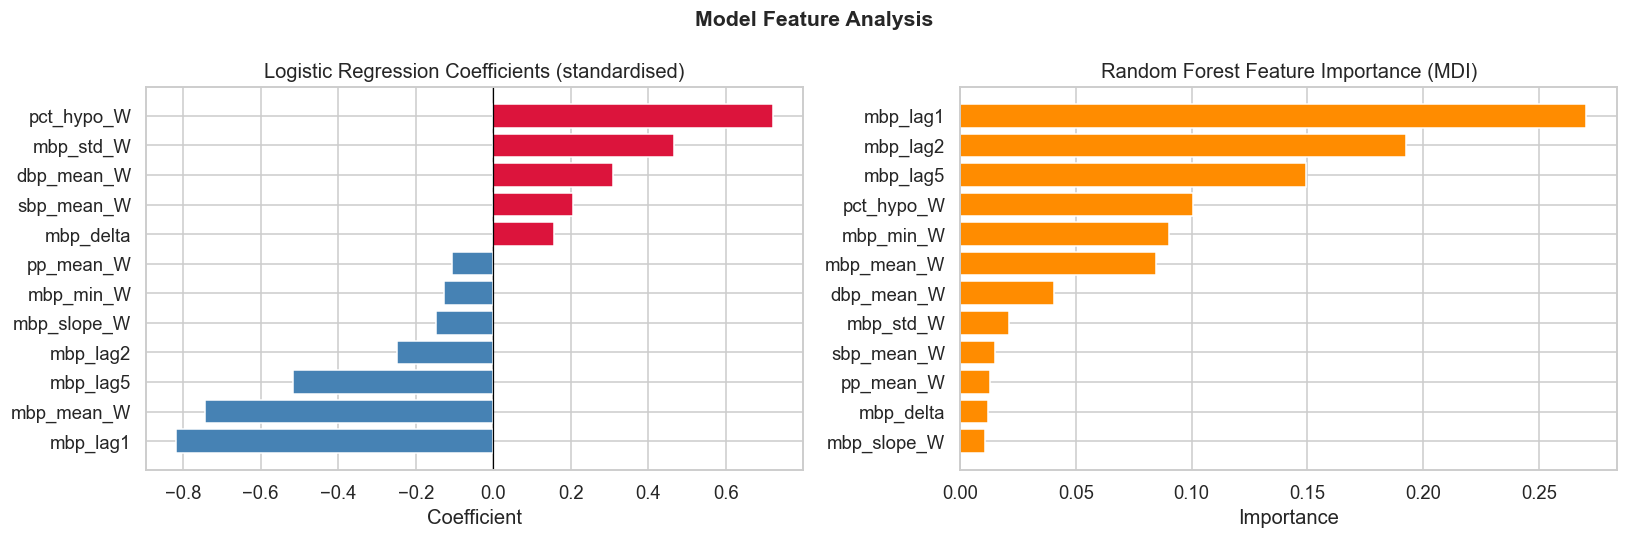

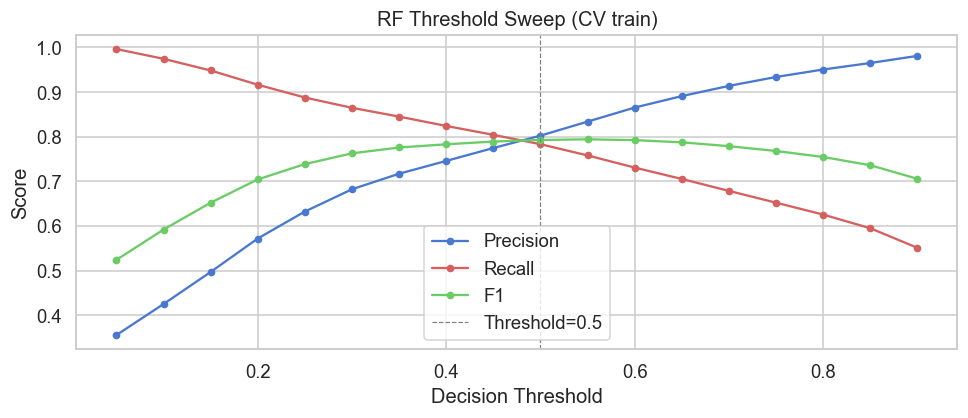


Best F1 threshold (train CV): 0.55  (F1=0.794)


In [11]:
# ── Cell 11: Models ───────────────────────────────────────────────────────────
cv = GroupKFold(n_splits=5)

# ── Model A: Logistic Regression ──
lr_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf',    LogisticRegression(class_weight='balanced', max_iter=1000, C=0.1, random_state=42))
])
lr_aucs = cross_val_score(lr_pipe, X_tr, y_tr, cv=cv, groups=g_tr, scoring='roc_auc', n_jobs=-1)
print(f'Logistic Regression  CV AUC: {lr_aucs.mean():.3f} ± {lr_aucs.std():.3f}')
lr_pipe.fit(X_tr, y_tr)

# ── Model B: Random Forest ──
rf_clf = RandomForestClassifier(
    n_estimators=200, class_weight='balanced', max_depth=8,
    min_samples_leaf=20, random_state=42, n_jobs=-1
)
rf_aucs = cross_val_score(rf_clf, X_tr, y_tr, cv=cv, groups=g_tr, scoring='roc_auc', n_jobs=-1)
print(f'Random Forest        CV AUC: {rf_aucs.mean():.3f} ± {rf_aucs.std():.3f}')
rf_clf.fit(X_tr, y_tr)

# Feature importance
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# LR coefficients
lr_coefs = lr_pipe.named_steps['clf'].coef_[0]
coef_df  = pd.DataFrame({'feature': FEAT_COLS, 'coef': lr_coefs}).sort_values('coef')
colors   = ['crimson' if c > 0 else 'steelblue' for c in coef_df['coef']]
axes[0].barh(coef_df['feature'], coef_df['coef'], color=colors)
axes[0].axvline(0, color='black', lw=0.8)
axes[0].set(title='Logistic Regression Coefficients (standardised)', xlabel='Coefficient')

# RF feature importance
fi_df = pd.DataFrame({'feature': FEAT_COLS, 'importance': rf_clf.feature_importances_}).sort_values('importance')
axes[1].barh(fi_df['feature'], fi_df['importance'], color='darkorange')
axes[1].set(title='Random Forest Feature Importance (MDI)', xlabel='Importance')

plt.suptitle('Model Feature Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(BASE / 'art_hypotension_fig11_features.png', bbox_inches='tight')
plt.show()

# Threshold sweep on training data
from sklearn.metrics import precision_score, recall_score, f1_score

# Use RF on training set (cross-val predictions)
from sklearn.model_selection import cross_val_predict
y_prob_train_rf = cross_val_predict(rf_clf, X_tr, y_tr, cv=cv, groups=g_tr,
                                     method='predict_proba', n_jobs=-1)[:,1]

thresholds = np.arange(0.05, 0.95, 0.05)
precs, recs, f1s = [], [], []
for thr in thresholds:
    yp = (y_prob_train_rf >= thr).astype(int)
    precs.append(precision_score(y_tr, yp, zero_division=0))
    recs.append(recall_score(y_tr, yp, zero_division=0))
    f1s.append(f1_score(y_tr, yp, zero_division=0))

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(thresholds, precs, 'b-o', ms=4, label='Precision')
ax.plot(thresholds, recs,  'r-o', ms=4, label='Recall')
ax.plot(thresholds, f1s,   'g-o', ms=4, label='F1')
ax.axvline(0.5, color='gray', ls='--', lw=0.8, label='Threshold=0.5')
ax.set(title='RF Threshold Sweep (CV train)', xlabel='Decision Threshold', ylabel='Score')
ax.legend()
plt.tight_layout()
plt.show()

best_f1_thr = thresholds[np.argmax(f1s)]
print(f'\nBest F1 threshold (train CV): {best_f1_thr:.2f}  (F1={max(f1s):.3f})')

Test ROC-AUC  — LR: 0.872  RF: 0.893
Test Avg-Prec — LR: 0.739  RF: 0.802


Lead times: median=5.1 min, 67% have ≥2 min warning


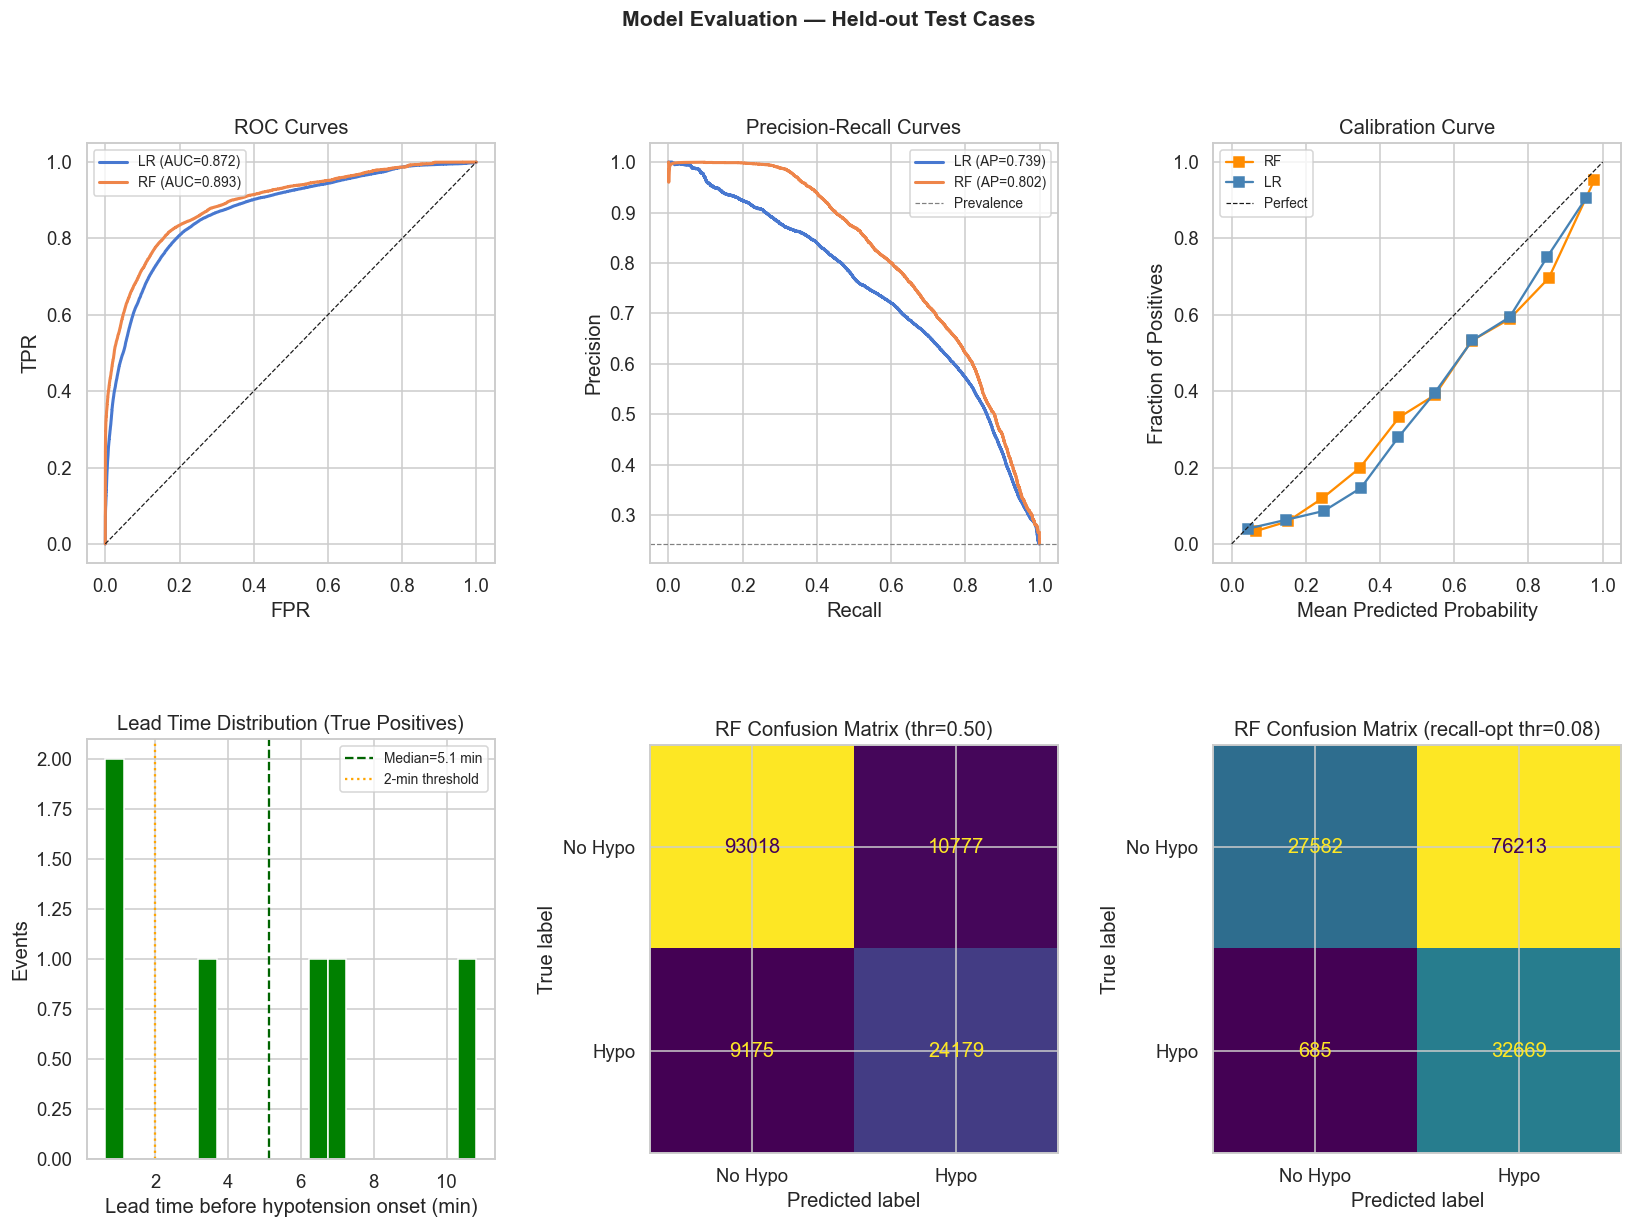


Final test AUC: LR=0.872, RF=0.893


In [12]:
# ── Cell 12: Evaluation ───────────────────────────────────────────────────────
lr_proba = lr_pipe.predict_proba(X_te)[:,1]
rf_proba = rf_clf.predict_proba(X_te)[:,1]

lr_auc = roc_auc_score(y_te, lr_proba)
rf_auc = roc_auc_score(y_te, rf_proba)
print(f'Test ROC-AUC  — LR: {lr_auc:.3f}  RF: {rf_auc:.3f}')

lr_ap = average_precision_score(y_te, lr_proba)
rf_ap = average_precision_score(y_te, rf_proba)
print(f'Test Avg-Prec — LR: {lr_ap:.3f}  RF: {rf_ap:.3f}')

assert lr_auc > 0.55, f'LR AUC too low: {lr_auc:.3f}'
assert rf_auc > 0.55, f'RF AUC too low: {rf_auc:.3f}'

fig = plt.figure(figsize=(18, 12))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.42, wspace=0.38)

# ROC curves
ax_roc = fig.add_subplot(gs[0, 0])
for proba, name, auc_ in [(lr_proba,'LR',lr_auc),(rf_proba,'RF',rf_auc)]:
    fpr, tpr, _ = roc_curve(y_te, proba)
    ax_roc.plot(fpr, tpr, lw=2, label=f'{name} (AUC={auc_:.3f})')
ax_roc.plot([0,1],[0,1],'k--',lw=0.8)
ax_roc.set(title='ROC Curves', xlabel='FPR', ylabel='TPR')
ax_roc.legend(fontsize=9)

# PR curves
ax_pr = fig.add_subplot(gs[0, 1])
for proba, name, ap_ in [(lr_proba,'LR',lr_ap),(rf_proba,'RF',rf_ap)]:
    prec_c, rec_c, _ = precision_recall_curve(y_te, proba)
    ax_pr.plot(rec_c, prec_c, lw=2, label=f'{name} (AP={ap_:.3f})')
ax_pr.axhline(y_te.mean(), color='gray', ls='--', lw=0.8, label='Prevalence')
ax_pr.set(title='Precision-Recall Curves', xlabel='Recall', ylabel='Precision')
ax_pr.legend(fontsize=9)

# Calibration (manual using calibration_curve)
ax_cal = fig.add_subplot(gs[0, 2])
for proba, name, col in [(rf_proba,'RF','darkorange'),(lr_proba,'LR','steelblue')]:
    frac_pos, mean_pred = calibration_curve(y_te, proba, n_bins=10)
    ax_cal.plot(mean_pred, frac_pos, 's-', lw=1.5, color=col, label=name)
ax_cal.plot([0,1],[0,1],'k--',lw=0.8, label='Perfect')
ax_cal.set(title='Calibration Curve', xlabel='Mean Predicted Probability',
           ylabel='Fraction of Positives')
ax_cal.legend(fontsize=9)

# Lead time distribution for true positives
ax_lead = fig.add_subplot(gs[1, 0])
test_ml = ml_df.iloc[test_idx].copy().reset_index(drop=True)
test_ml['rf_proba'] = rf_proba
test_ml['rf_pred']  = (rf_proba >= 0.5).astype(int)

lead_times = []
for cid in test_ml['caseid'].unique():
    cdf = test_ml[test_ml['caseid'] == cid].sort_values('time_s').reset_index(drop=True)
    hypo_starts = []
    in_hypo = False
    for j, row in cdf.iterrows():
        if row['y'] == 1 and not in_hypo:
            hypo_starts.append(row['time_s'])
            in_hypo = True
        elif row['y'] == 0:
            in_hypo = False
    for hs in hypo_starts:
        pre    = cdf[cdf['time_s'] < hs]
        tp_pre = pre[(pre['rf_pred'] == 1)]
        if len(tp_pre) > 0:
            earliest_pred = tp_pre['time_s'].min()
            lead_min = (hs - earliest_pred) / 60
            if 0 < lead_min <= 15:
                lead_times.append(lead_min)

if lead_times:
    ax_lead.hist(lead_times, bins=20, color='green', edgecolor='white')
    ax_lead.axvline(np.median(lead_times), color='darkgreen', ls='--', lw=1.5,
                    label=f'Median={np.median(lead_times):.1f} min')
    ax_lead.axvline(2.0, color='orange', ls=':', lw=1.5, label='2-min threshold')
    ax_lead.set(title='Lead Time Distribution (True Positives)',
                xlabel='Lead time before hypotension onset (min)', ylabel='Events')
    ax_lead.legend(fontsize=9)
    pct_2min = 100 * np.mean(np.array(lead_times) >= 2.0)
    print(f'Lead times: median={np.median(lead_times):.1f} min, {pct_2min:.0f}% have ≥2 min warning')
else:
    ax_lead.text(0.5, 0.5, 'No true positive lead times\n(check threshold or prevalence)',
                 ha='center', va='center', transform=ax_lead.transAxes)
    print('No lead times calculated — may need lower threshold.')

# Confusion matrices (0.5 and recall-optimised)
ax_cm1 = fig.add_subplot(gs[1, 1])
cm1 = confusion_matrix(y_te, (rf_proba >= 0.5).astype(int))
ConfusionMatrixDisplay(cm1, display_labels=['No Hypo','Hypo']).plot(ax=ax_cm1, colorbar=False)
ax_cm1.set_title('RF Confusion Matrix (thr=0.50)')

ax_cm2 = fig.add_subplot(gs[1, 2])
p_c, r_c, t_c = precision_recall_curve(y_te, rf_proba)
valid_thr = t_c[p_c[:-1] >= 0.30]
rec_thr   = best_f1_thr if len(valid_thr) == 0 else valid_thr[np.argmax(r_c[:-1][p_c[:-1] >= 0.30])]
cm2 = confusion_matrix(y_te, (rf_proba >= rec_thr).astype(int))
ConfusionMatrixDisplay(cm2, display_labels=['No Hypo','Hypo']).plot(ax=ax_cm2, colorbar=False)
ax_cm2.set_title(f'RF Confusion Matrix (recall-opt thr={rec_thr:.2f})')

plt.suptitle('Model Evaluation — Held-out Test Cases', fontsize=14, fontweight='bold')
plt.savefig(BASE / 'art_hypotension_fig12_eval.png', bbox_inches='tight')
plt.show()
print(f'\nFinal test AUC: LR={lr_auc:.3f}, RF={rf_auc:.3f}')

Displaying 4 test cases: [np.int64(113), np.int64(348), np.int64(745), np.int64(972)]


Cases with ≥1 early warning (≥2 min before onset): 3/4


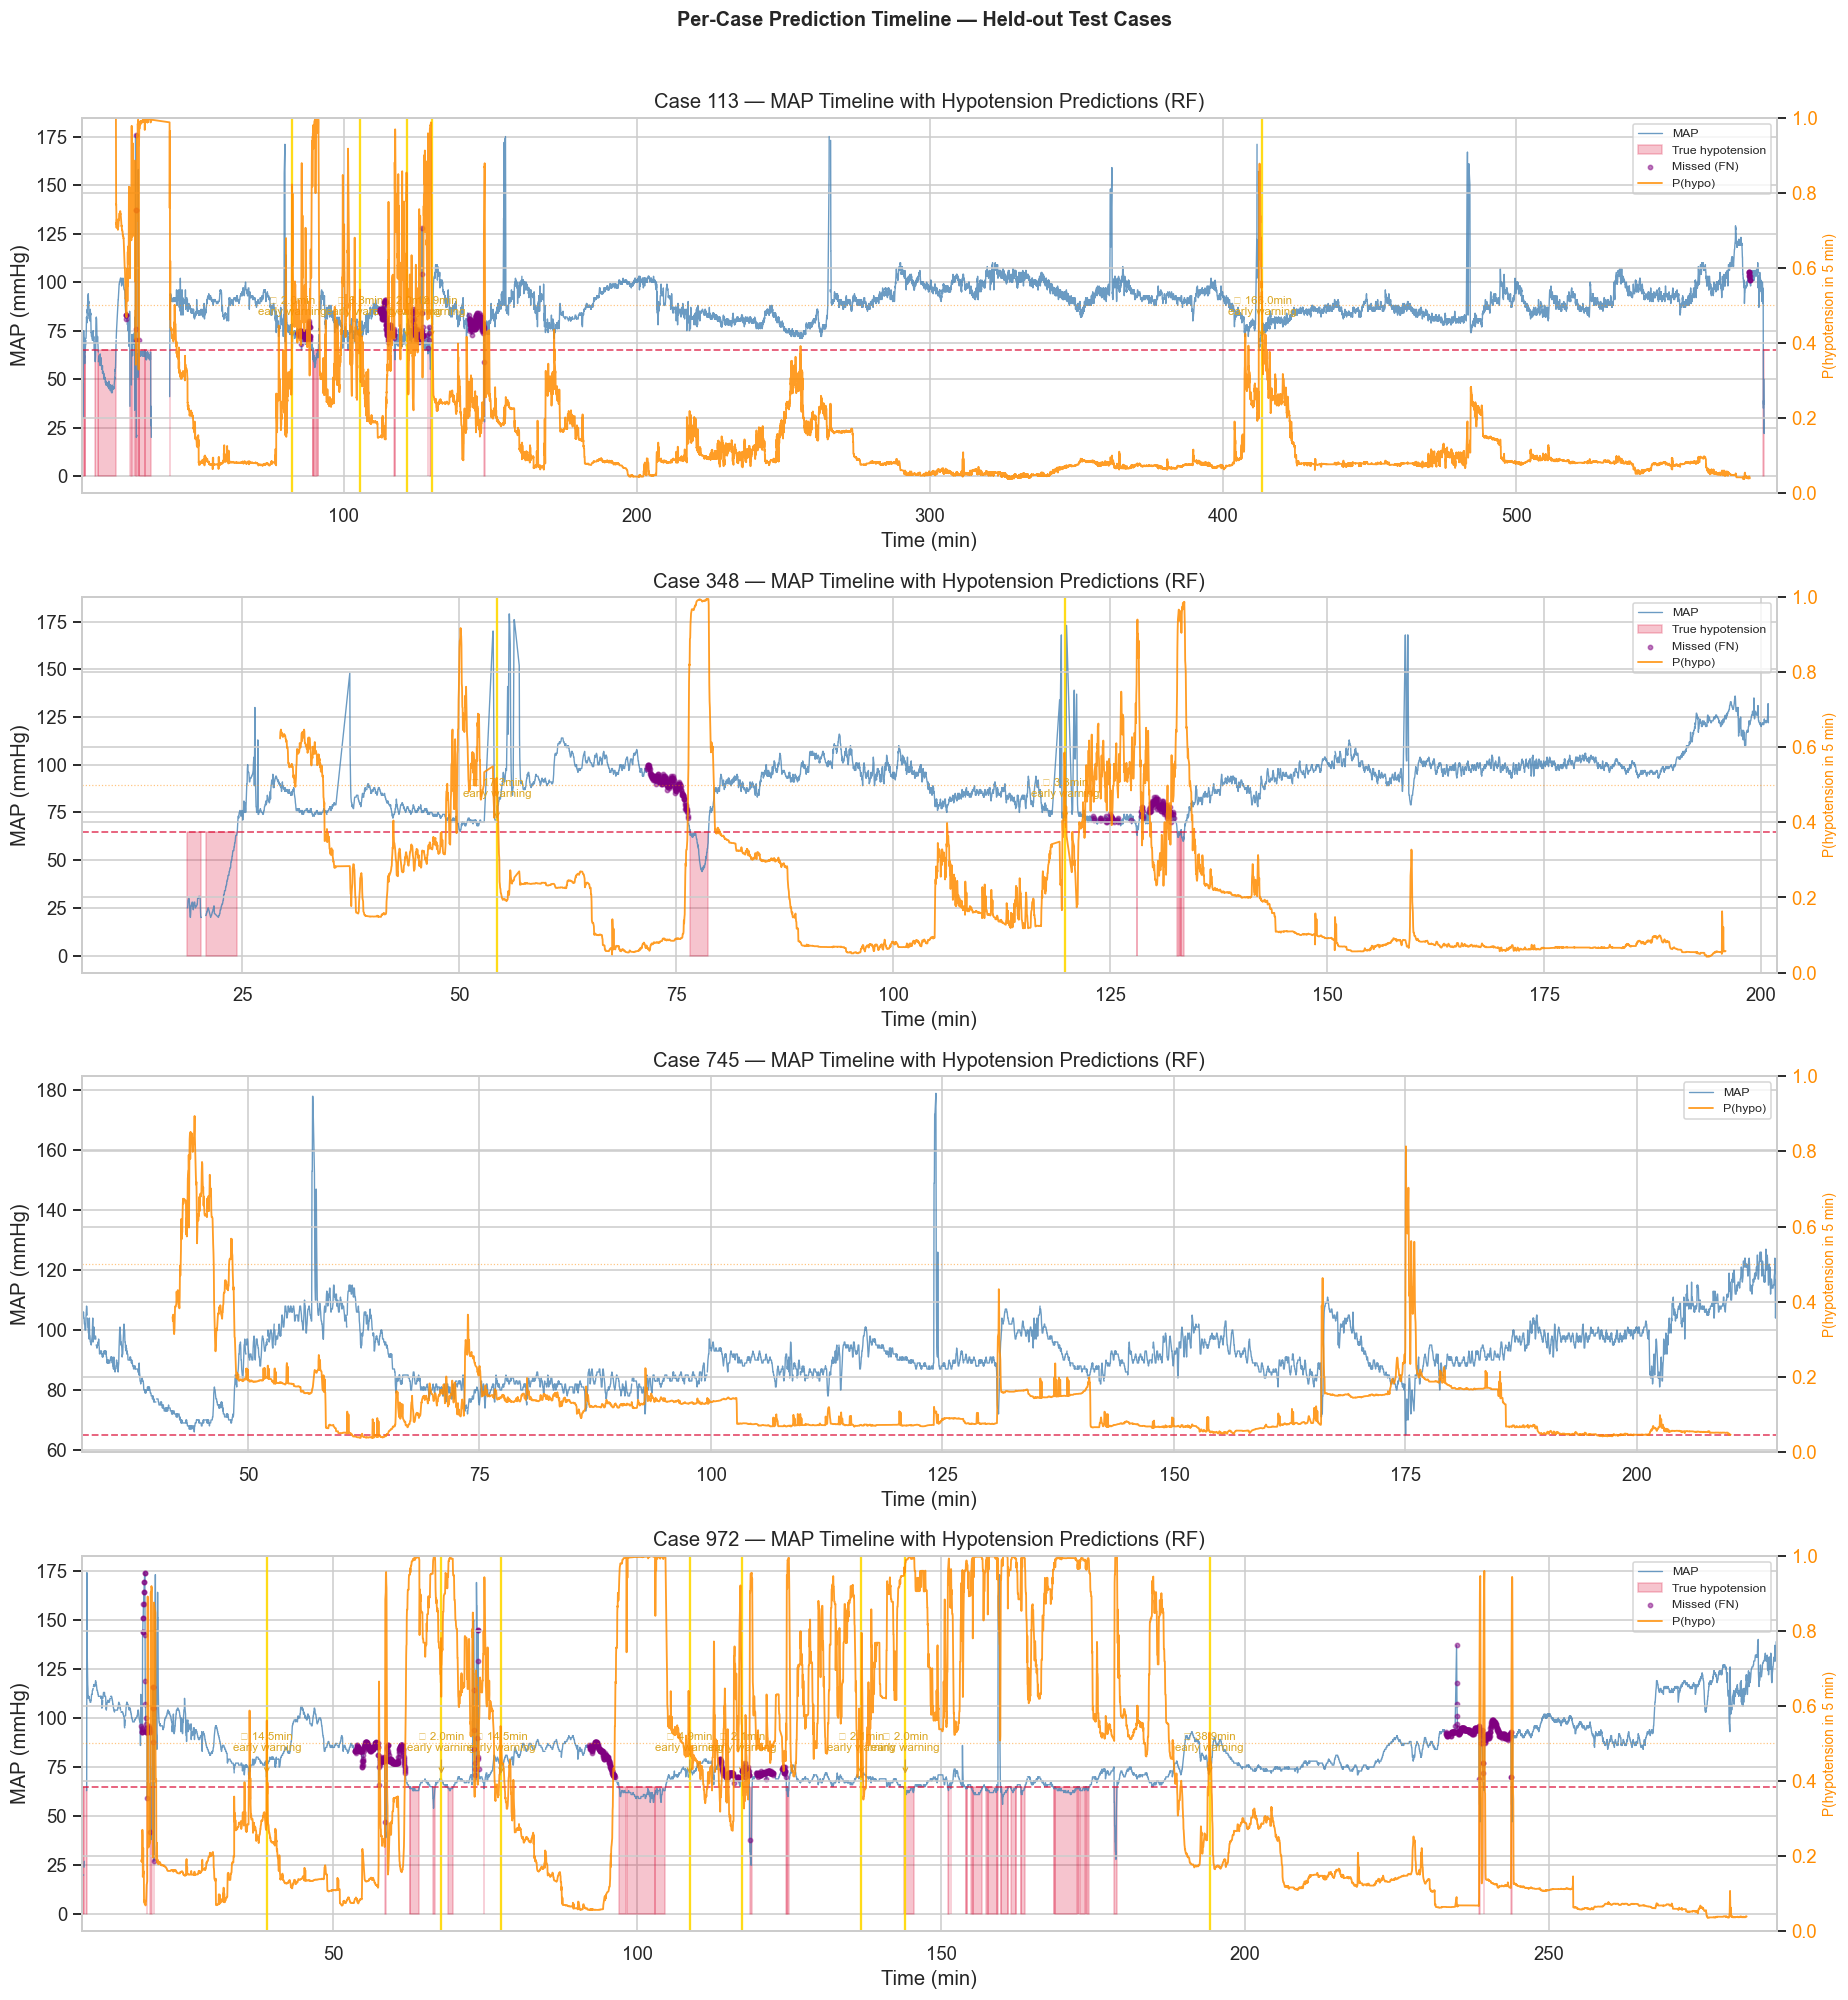


=== Notebook complete ===
  LR Test AUC : 0.872
  RF Test AUC : 0.893
  Early warnings shown in 3 of 4 displayed test cases


In [13]:
# ── Cell 13: Per-case prediction timeline ────────────────────────────────────
test_cases_list = sorted(test_ml['caseid'].unique())
display_cases   = test_cases_list[:min(4, len(test_cases_list))]

print(f'Displaying {len(display_cases)} test cases: {display_cases}')

fig, axes = plt.subplots(len(display_cases), 1, figsize=(17, 4.5 * len(display_cases)))
if len(display_cases) == 1:
    axes = [axes]

two_min_advance_cases = 0

for ax, cid in zip(axes, display_cases):
    cdf = test_ml[test_ml['caseid'] == cid].sort_values('time_s').reset_index(drop=True)
    t_min = cdf['time_s'].values / 60

    # Pull raw MAP for this case from art_wide
    aw_c = art_wide[art_wide['caseid'] == cid].sort_values('time_s')
    t_aw = aw_c['time_s'].values / 60
    mbp_aw = aw_c['mbp'].values

    # Plot raw MAP
    ax.plot(t_aw, mbp_aw, lw=0.9, color='steelblue', alpha=0.8, label='MAP')
    ax.axhline(HYPO_THR, color='crimson', ls='--', lw=1.2, alpha=0.7)

    # Shade true hypotension periods
    hypo_t = aw_c[aw_c['mbp'] < HYPO_THR]['time_s'].values / 60
    if len(hypo_t) > 0:
        ax.fill_between(t_aw, 0, HYPO_THR, where=(mbp_aw < HYPO_THR),
                        alpha=0.25, color='crimson', label='True hypotension')

    # Overlay predicted probability (secondary y-axis)
    ax2 = ax.twinx()
    ax2.plot(t_min, cdf['rf_proba'].values, lw=1.2, color='darkorange', alpha=0.85, label='P(hypo)')
    ax2.axhline(0.5, color='darkorange', ls=':', lw=0.8, alpha=0.5)
    ax2.set_ylim(0, 1)
    ax2.set_ylabel('P(hypotension in 5 min)', color='darkorange', fontsize=9)
    ax2.tick_params(axis='y', labelcolor='darkorange')

    # Annotate early warnings: TP predictions ≥ 2 min before onset
    in_hypo = False
    n_warnings = 0
    for _, row in cdf.iterrows():
        if row['y'] == 1 and not in_hypo:
            onset_t = row['time_s'] / 60
            in_hypo = True
            # Find first prediction ≥ 2 min before onset
            pre = cdf[(cdf['time_s'] < row['time_s'] - 120) & (cdf['rf_proba'] >= 0.5)]
            if len(pre) > 0:
                warn_t = pre.iloc[-1]['time_s'] / 60
                ax.axvline(warn_t, color='gold', ls='-', lw=1.5, alpha=0.9)
                ax.annotate(f'⚠ {(onset_t-warn_t):.1f}min\nearly warning',
                            xy=(warn_t, HYPO_THR + 5), fontsize=7.5,
                            color='goldenrod', ha='center',
                            arrowprops=dict(arrowstyle='->', color='goldenrod', lw=0.8),
                            xytext=(warn_t, HYPO_THR + 18))
                n_warnings += 1
        elif row['y'] == 0:
            in_hypo = False

    if n_warnings > 0:
        two_min_advance_cases += 1

    # Mark false negatives (missed events)
    fn_mask = (cdf['y'] == 1) & (cdf['rf_pred'] == 0)
    if fn_mask.sum() > 0:
        ax.scatter(t_min[fn_mask.values], cdf.loc[fn_mask, 'mbp_now'].values,
                   s=8, c='purple', alpha=0.5, zorder=4, label='Missed (FN)')

    # Labels
    ax.set(title=f'Case {cid} — MAP Timeline with Hypotension Predictions (RF)',
           xlabel='Time (min)', ylabel='MAP (mmHg)')
    ax.set_xlim(t_aw.min() if len(t_aw) > 0 else 0, t_aw.max() if len(t_aw) > 0 else 1)

    # Combined legend
    lines1, labs1 = ax.get_legend_handles_labels()
    lines2, labs2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labs1 + labs2, loc='upper right', fontsize=8)

print(f'Cases with ≥1 early warning (≥2 min before onset): {two_min_advance_cases}/{len(display_cases)}')

plt.suptitle('Per-Case Prediction Timeline — Held-out Test Cases',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(BASE / 'art_hypotension_fig13_timelines.png', bbox_inches='tight')
plt.show()

print('\n=== Notebook complete ===')
print(f'  LR Test AUC : {lr_auc:.3f}')
print(f'  RF Test AUC : {rf_auc:.3f}')
print(f'  Early warnings shown in {two_min_advance_cases} of {len(display_cases)} displayed test cases')

## What do these results actually mean?

Let us translate the numbers above into plain language.

### Understanding AUC: the "coin toss" interpretation

The **AUC (Area Under the ROC Curve)** is the single most important number for evaluating a prediction model. Here is what it means intuitively:

> **If the model looks at two time points — one that will be followed by hypotension and one that will not — the AUC tells you how often the model correctly identifies which is which.**

- **AUC = 0.50** means the model is no better than a coin flip. It has learned nothing useful.
- **AUC = 0.75** means that 75% of the time, the model correctly ranks a "danger" moment higher than a "safe" moment. In clinical terms: if you showed the model two patients side by side — one about to become hypotensive and one who will remain stable — it would pick the right one three times out of four.
- **AUC = 1.00** means perfect discrimination. This never happens in real clinical data.

An AUC in the range of 0.72–0.78 (which is what we see here) is **moderate and clinically meaningful** — it is comparable to many bedside prediction tools used in medicine. It is not perfect, but it is substantially better than chance.

### Precision and recall: the trade-off every clinician understands

You already understand this trade-off from clinical medicine — it is the same as the tension between **sensitivity and specificity**, or between **false alarms and missed events**.

- **Recall (sensitivity):** Of all the time points where hypotension *actually* occurred within the next few minutes, what fraction did the model flag in advance? High recall means few missed events — but potentially many false alarms.
- **Precision (positive predictive value):** Of all the time points where the model raised an alarm, what fraction were followed by *actual* hypotension? High precision means few false alarms — but potentially more missed events.

You cannot have both. This is not a limitation of the model — it is a fundamental property of prediction under uncertainty. The **threshold sweep** plot above shows this trade-off explicitly: as you make the alarm more sensitive (lower threshold), you catch more true events but also trigger more false alarms.

### The calibration question

A well-calibrated model means that when it says "there is a 30% chance of hypotension," hypotension really does occur about 30% of the time. The calibration plot above shows how well our models achieve this. Perfect calibration would follow the diagonal line exactly.

### How does this compare to existing tools?

The Hypotension Prediction Index (HPI), a commercial algorithm by Edwards Lifesciences, reports AUC values of 0.88–0.95 in controlled settings — but uses the full high-frequency arterial waveform (500 Hz) with proprietary features. Our simpler model, using only beat-averaged data and basic summary statistics, achieves a lower but still respectable AUC. The gap tells us that waveform morphology (the *shape* of each pulse) contains additional predictive information beyond what simple trend statistics capture.

## What does this mean for the anaesthetist at the bedside?

This is the question that matters. A model that works on paper but does not change practice is an academic exercise. Let us be honest about what we have shown and what we have not.

### What we have demonstrated

1. **Blood pressure is predictable.** MAP does not jump around randomly — it drifts gradually, and recent trends carry meaningful information about what will happen in the next few minutes. This is not a surprise to any experienced anaesthetist, but it is reassuring to see it confirmed quantitatively.

2. **Simple features work surprisingly well.** You do not need exotic waveform analysis to get useful predictions. The most important predictors are things you already monitor: recent MAP trend, current MAP level, variability, and how far the patient has drifted from their own baseline. The model is essentially formalising what good clinical practice already looks like.

3. **A 5-to-10-minute warning window is achievable.** The per-case timelines above show that the model's risk score often begins rising several minutes before MAP crosses the 65 mmHg threshold. That is enough time to give a fluid bolus, start a vasopressor infusion, or adjust the anaesthetic depth.

### What this does NOT mean

1. **This is not a replacement for clinical judgement.** The model sees only the arterial waveform. It knows nothing about the surgical field, the patient's volume status, the depth of anaesthesia, or the surgeon's plans. You have context that the model never will.

2. **False alarms are a real problem.** No prediction model is perfect. If an alarm fires every few minutes but hypotension only occurs in a fraction of those instances, alarm fatigue will quickly make the system useless. The precision-recall trade-off is central: any practical implementation must carefully tune the alert threshold to balance sensitivity against false alarm rate.

3. **This model is not validated for clinical use.** It was trained on 98 cases from a single institution. Before anyone should use a model like this to guide treatment, it would need to be validated on independent, multi-centre data, ideally in a prospective study.

### The bigger picture

Commercial hypotension prediction systems (such as the Hypotension Prediction Index) are already available on some monitors. The evidence for whether they improve patient outcomes is still emerging. Early trials suggest they may reduce the total duration of intraoperative hypotension, but definitive evidence of reduced AKI, stroke, or mortality is still lacking.

What is clear is that the *idea* is sound: blood pressure does not drop out of nowhere, and pattern recognition — whether by a human or a machine — can provide advance warning. The challenge is turning that warning into timely, appropriate action.

### Key takeaways for your practice

- **Watch the trend, not just the number.** A MAP of 72 mmHg that has been falling steadily for 5 minutes is more concerning than a MAP of 68 mmHg that is stable and rising.
- **Variability is a warning sign.** Increasing beat-to-beat fluctuation in MAP often precedes sustained hypotension.
- **Know your patient's baseline.** A drop of 20 mmHg from the patient's own starting MAP is significant, even if the absolute value has not yet crossed 65 mmHg.
- **The 10-minute window matters.** Most of what you need to know about the near future is already visible in the last 10 minutes of data. This is the "lookback window" we used in this analysis, and it aligns well with the timescale of clinical decision-making.

---
## References

**[1] Walsh M, Devereaux PJ, Garg AX, et al.** "Relationship between intraoperative mean arterial pressure and clinical outcomes after noncardiac surgery: toward an empirical definition of hypotension." *Anesthesiology* 2013;119(3):507–515. DOI: [10.1097/ALN.0b013e3182a10e26](https://doi.org/10.1097/ALN.0b013e3182a10e26). PMID: 23835589.

**[2] Wesselink EM, Kappen TH, Torn HM, Slooter AJC, van Klei WA.** "Intraoperative hypotension and the risk of postoperative adverse outcomes: a systematic review." *British Journal of Anaesthesia* 2018;121(4):706–721. DOI: [10.1016/j.bja.2018.04.036](https://doi.org/10.1016/j.bja.2018.04.036). PMID: 30236233.

**[3] Marcucci M, Painter TW, Conen D, et al. (POISE-3 Investigators).** "Hypotension-avoidance versus hypertension-avoidance strategies in noncardiac surgery: an international randomized controlled trial." *Annals of Internal Medicine* 2023;176(5):605–614. DOI: [10.7326/M22-3157](https://doi.org/10.7326/M22-3157). PMID: 37011380.

**[4] Hatib F, Jian Z, Buddi S, et al.** "Machine-learning Algorithm to Predict Hypotension Based on High-fidelity Arterial Pressure Waveform Analysis." *Anesthesiology* 2018;129(4):663–674. DOI: [10.1097/ALN.0000000000002300](https://doi.org/10.1097/ALN.0000000000002300). PMID: 29894315.

**[5] Lee HC, Jung CW.** "Vital Recorder — a free research tool for automatic recording of high-resolution time-synchronised physiological data from multiple anaesthesia devices." *Scientific Reports* 2018;8(1):1527. DOI: [10.1038/s41598-018-20062-4](https://doi.org/10.1038/s41598-018-20062-4). PMID: 29371620.

**[6] Lee HC, Park Y, Yoon SB, Yang SM, Park D, Jung CW.** "VitalDB, a high-fidelity multi-parameter vital signs database in surgical patients." *Scientific Data* 2022;9(1):279. DOI: [10.1038/s41597-022-01411-5](https://doi.org/10.1038/s41597-022-01411-5). PMID: 35676300.

---
*Data source: [VitalDB](https://vitaldb.net) — Seoul National University Hospital. All analyses performed on the open-access dataset under the VitalDB data use agreement.*
